## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

## Load Feature Dataset & P-value Rank
* Results of ML3-1 and ML3-2

In [2]:
FeatureData = pd.read_csv(
    "../ML3/data/FeatureData.csv",
    header=None,
)
FeatureData.shape

(270, 360)

In [3]:
P_value_Rank = pd.read_csv(
    "../ML3/data/P_value_Rank.csv",
    header=None,
)
P_value_Rank

,0,1
0,198.0,4.762393e-81
1,110.0,5.270311e-77
2,170.0,4.615377e-76
3,133.0,5.747675e-74
4,134.0,7.585991e-74
...,...,...
265,85.0,8.999631e-01
266,95.0,9.358453e-01
267,255.0,9.450087e-01
268,217.0,9.695416e-01


## Select Target Features for Demensionality Reduction Based on P-value

In [4]:
# Select features from StartRank to StartRank+Num
StartRank = 1
Number = 30

SelectedFeatues = np.zeros((Number, FeatureData.shape[1]))

s = 0
for i in range(StartRank, StartRank + Number):

    index = int(P_value_Rank.iloc[i - 1, 0])
    SelectedFeatues[s, :] = FeatureData.iloc[index, :].values
    s += 1

FeatureSelected = pd.DataFrame(SelectedFeatues).T
FeatureSelected

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.481424,1.268380,12.777754,0.654730,0.428672,-2.7173,1.620323,0.167877,0.028183,1.265919,...,0.095414,1.449463,1.583225,0.731190,0.534615,1.970872,2.142956,1.757904,-1.389085,1.548169
1,1.478799,1.428695,13.280290,0.649638,0.421593,-2.7250,1.597625,0.167090,0.027919,1.299383,...,0.095599,1.482249,1.645840,0.732929,0.537179,1.911625,2.389259,1.902583,-1.373162,1.664589
2,1.482299,1.430385,12.905222,0.641463,0.411441,-2.7224,1.625148,0.172784,0.029854,1.281556,...,0.095412,1.493831,1.640594,0.731354,0.534865,1.968504,2.347563,1.839163,-1.401283,1.613160
3,1.477326,1.428752,13.079692,0.638104,0.406741,-2.7520,1.575759,0.172377,0.029714,1.303882,...,0.095632,1.438521,1.586325,0.735156,0.540450,1.875148,2.353907,1.798335,-1.398744,1.571165
4,1.478828,1.435017,12.862634,0.627408,0.393194,-2.7517,1.564056,0.171432,0.029389,1.295184,...,0.095620,1.441050,1.596723,0.737189,0.543447,1.854403,2.308322,1.769507,-1.409967,1.545715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.489518,1.433793,12.231166,0.671847,0.450741,-2.8459,1.578616,0.180131,0.032447,1.271762,...,0.095817,1.335111,1.488136,0.739743,0.547219,1.895502,2.205750,1.679486,-1.447667,1.474148
356,1.485393,1.478560,11.902660,0.661014,0.436692,-2.8570,1.540658,0.184310,0.033970,1.269566,...,0.095778,1.328678,1.485636,0.741043,0.549134,1.839912,2.190754,1.649162,-1.452517,1.458351
357,1.486447,1.478878,11.811784,0.681616,0.464223,-2.8318,1.588620,0.185856,0.034543,1.275704,...,0.095855,1.349357,1.503535,0.738831,0.545871,1.908137,2.095340,1.603096,-1.448879,1.406252
358,1.489181,1.470033,12.339840,0.672230,0.451389,-2.8524,1.522793,0.171050,0.029258,1.273485,...,0.095829,1.407482,1.561305,0.737491,0.543893,1.816432,2.269790,1.724622,-1.438261,1.510040


### Standardization of features

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected)
pd.DataFrame(FeatureSelected_std)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.776847,-3.420112,0.469637,-0.171224,-0.180105,0.773818,0.726666,-1.405927,-1.381434,-1.841564,...,-0.841828,0.955834,0.630511,-1.676357,-1.676805,1.150744,-1.036622,0.291819,1.077970,0.437809
1,-1.526489,-0.292716,1.311470,-0.381671,-0.402063,0.708676,0.352155,-1.512154,-1.480919,1.233430,...,-0.184274,1.588483,1.738461,-1.049556,-1.048898,0.324519,1.667064,2.137192,1.584065,2.159386
2,-0.526880,-0.259748,0.683167,-0.719494,-0.720387,0.730672,0.806293,-0.743554,-0.750557,-0.404665,...,-0.850615,1.811973,1.645642,-1.617501,-1.615593,1.117717,1.209363,1.328276,0.690309,1.398872
3,-1.947166,-0.291613,0.975434,-0.858271,-0.867777,0.480255,-0.008646,-0.798420,-0.803505,1.646881,...,-0.066091,0.744706,0.685365,-0.246405,-0.248233,-0.184173,1.279003,0.807513,0.770988,0.777862
4,-1.518389,-0.169397,0.611825,-1.300261,-1.292566,0.482793,-0.201750,-0.926091,-0.926229,0.847654,...,-0.108186,0.793503,0.869357,0.486315,0.485603,-0.473467,0.778615,0.439825,0.414305,0.401520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.534911,-0.193261,-0.445990,0.536100,0.511937,-0.314142,0.038488,0.248310,0.228124,-1.304660,...,0.593625,-1.250702,-1.052031,1.407219,1.409167,0.099680,-0.347324,-0.708382,-0.783891,-0.656796
356,0.356688,0.680043,-0.996295,0.088451,0.071388,-0.408049,-0.587832,0.812514,0.803010,-1.506446,...,0.453190,-1.374831,-1.096270,1.875884,1.878075,-0.675541,-0.511946,-1.095166,-0.938045,-0.890393
357,0.657705,0.686250,-1.148526,0.939807,0.934670,-0.194856,0.203567,1.021315,1.019108,-0.942348,...,0.726120,-0.975816,-0.779554,1.078615,1.079174,0.275882,-1.559304,-1.682735,-0.822419,-1.660818
358,1.438797,0.513686,-0.263944,0.551953,0.532235,-0.369132,-0.882609,-0.977644,-0.975592,-1.146249,...,0.635875,0.145764,0.242660,0.595402,0.594936,-1.002981,0.355644,-0.132681,-0.484962,-0.126028


## t-SNE Implementation

In [7]:
from sklearn.manifold import TSNE  # Import a package for t-SNE

dim = 2
time_start = time.time()
tsne = TSNE(
    n_components=dim, verbose=1, perplexity=50, max_iter=500, random_state=1
)
# 'perplexity' is generally set to a value between 5 and 50.
tsne_results = tsne.fit_transform(FeatureSelected_std)

print(
    "\n\n t-SNE done! Time elapsed: {} seconds\n\n".format(
        time.time() - time_start
    )
)

pd.DataFrame(tsne_results)

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 360 samples in 0.000s...
[t-SNE] Computed neighbors for 360 samples in 1.369s...
[t-SNE] Computed conditional probabilities for sample 360 / 360
[t-SNE] Mean sigma: 1.880729
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.314762
[t-SNE] KL divergence after 500 iterations: 0.467883


 t-SNE done! Time elapsed: 1.5359933376312256 seconds




,0,1
0,-9.412018,-2.728613
1,-17.529345,-1.848591
2,-13.687891,-1.607496
3,-15.346423,-1.008596
4,-14.246557,3.418501
...,...,...
355,16.925842,2.356761
356,16.922365,1.785547
357,18.241198,-2.110587
358,11.388663,3.135637


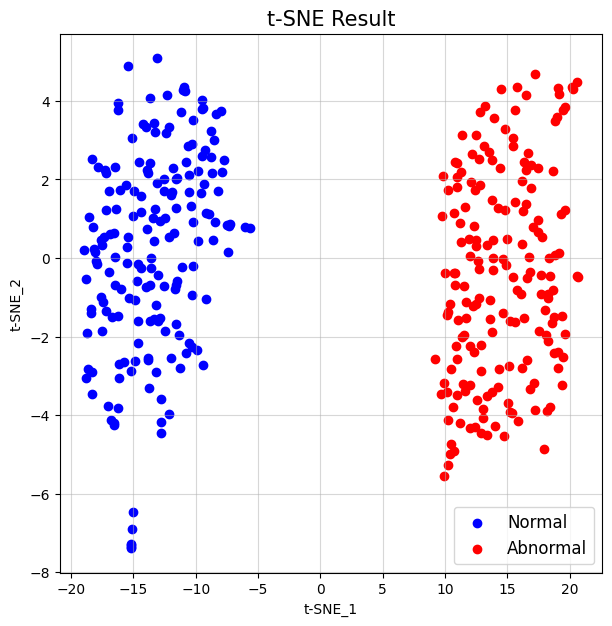

In [8]:
NoOfData = int(FeatureSelected.shape[0] / 2)

plt.figure(figsize=(7, 7))

plt.scatter(
    tsne_results[:NoOfData, 0],
    tsne_results[:NoOfData, 1],
    marker="o",
    label="Normal",
    c="b",
)
plt.scatter(
    tsne_results[NoOfData:, 0],
    tsne_results[NoOfData:, 1],
    marker="o",
    label="Abnormal",
    c="r",
)
plt.title("t-SNE Result", fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel("t-SNE_1")
plt.ylabel("t-SNE_2")

plt.show()

## Comparison with the t-SNE result of bottom 30 features (p-value)

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 360 samples in 0.000s...
[t-SNE] Computed neighbors for 360 samples in 0.012s...
[t-SNE] Computed conditional probabilities for sample 360 / 360
[t-SNE] Mean sigma: 1.989063
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.710171
[t-SNE] KL divergence after 500 iterations: 0.766504


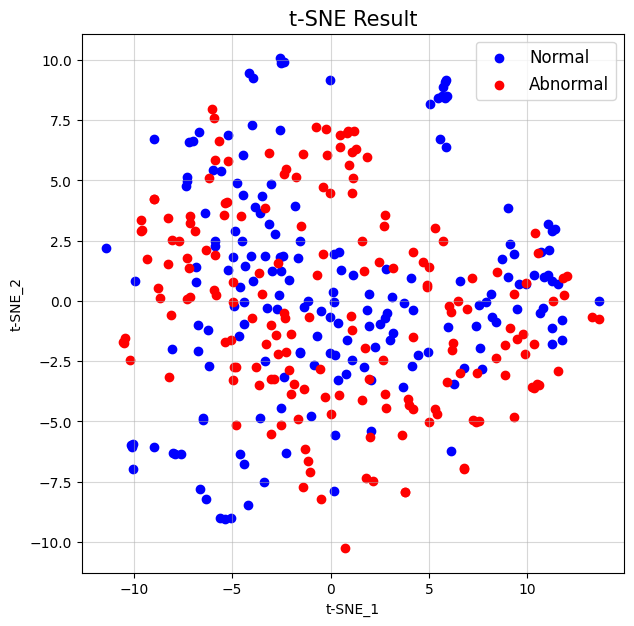

In [11]:
StartRank = 240
Number = 30

SelectedFeatues = np.zeros((Number, FeatureData.shape[1]))

s = 0
for i in range(StartRank, StartRank + Number):
    index = int(P_value_Rank.iloc[i - 1, 0])
    SelectedFeatues[s, :] = FeatureData.iloc[index, :].values
    s += 1

FeatureSelected_std = StandardScaler().fit_transform(
    pd.DataFrame(SelectedFeatues).T
)

dim = 2
tsne = TSNE(
    n_components=dim, verbose=1, perplexity=50, max_iter=500, random_state=1
)
tsne_results = tsne.fit_transform(FeatureSelected_std)


plt.figure(figsize=(7, 7))

plt.scatter(
    tsne_results[:NoOfData, 0],
    tsne_results[:NoOfData, 1],
    marker="o",
    label="Normal",
    c="b",
)
plt.scatter(
    tsne_results[NoOfData:, 0],
    tsne_results[NoOfData:, 1],
    marker="o",
    label="Abnormal",
    c="r",
)
plt.title("t-SNE Result", fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel("t-SNE_1")
plt.ylabel("t-SNE_2")

plt.show()